# TEXBAT EDA — cleanStatic vs ds7

Cel: zrozumieć strukturę przetworzonych obserwabli z odbiornika UT GRID dla scenariuszy:
- **cleanStatic** — czysty sygnał, baseline (label = 0)
- **ds7** — *power-matched + carrier-phase-aligned* spoofing (najtrudniejszy scenariusz w TEXBAT bez raw I/Q dla ds8 SCER)

**Kluczowy fakt o ds7** (per `texbat_ds7_and_ds8.pdf`):

| Czas [s] | Faza | Co się dzieje | Trudność detekcji |
|---|---|---|---|
| 0-110 | clean | Identyczne z cleanStatic | — |
| 110-130 | injection | Spoofer wstrzykiwany z phase rotation π/2→π, amplituda 0→2*Aa | łatwa-średnia (interferencja) |
| 130-150 | **stealth** | **C/N0, pseudorange ≈ clean!** Carrier phase rotated by π | **trudna** — killer test |
| 150-400 | code drift | Code phase rośnie 1.2 m/s, frequency-locked | średnia |
| 400-468 | walk | Czysta jazda kodu, ~382 m offset, 1.27 µs clock offset | łatwa-średnia |

Headline metric dla naszego modelu: **F1 na stealth phase 130-150s**.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

DATA = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/texbat')
print(f'TEXBAT root: {DATA}  exists={DATA.exists()}')
for sc in ['cleanStatic', 'ds2', 'ds3', 'ds7']:
    p = DATA / sc
    files = sorted(f.name for f in p.iterdir() if f.suffix == '.mat')
    print(f'  {sc}: {len(files)} .mat files')

TEXBAT root: /net/afscra/people/plgmateuszoracz/hackathon/data/texbat  exists=True
  cleanStatic: 9 .mat files
  ds2: 9 .mat files
  ds3: 9 .mat files
  ds7: 9 .mat files


In [17]:
# Column schemas per channeldef.txt / iqdef.txt etc.
# All .mat files store data column-major (cols × N) — must transpose after load.

CHANNEL_COLS = [
    'rrt_wk', 'rrt_sow',           # 1-2 RRT week + seconds of week (RRT starts at 0 at receiver init)
    'ort_wk', 'ort_sow', 'ort_frac',# 3-5 ORT (true GPS time)
    'doppler_hz', 'carrier_phase', 'pseudorange_m', 'cn0_dbhz',  # 6-9 observables
    'valid_flag', 'error_flag',    # 10-11 (error_flag bit 1 = spoofing detected by GRID)
    'channel_status', 'signal_type', 'txid'  # 12-14
]
IQ_COLS = [
    'rrt_wk', 'rrt_sow', 'ort_wk', 'ort_sow', 'ort_frac',  # 1-5 time
    'carrier_phase', 'I', 'Q', 'data_symbol', 'signal_type', 'txid'  # 6-11
]
NAVSOL_COLS = [
    'ort_wk', 'ort_sow', 'ort_frac',  # 1-3 time
    'X', 'Y', 'Z',                    # 4-6 ECEF position
    'deltR_m',                        # 7 clock error (m)
    'Xdot', 'Ydot', 'Zdot',           # 8-10 ECEF velocity
    'deltRdot_mps',                   # 11 clock rate (m/s)
    'sol_flag'                         # 12 fix quality (docs say col 13 NIS but our file has 12)
]

def load_mat_table(path, cols):
    """Load TEXBAT .mat with single variable, transpose so rows=samples, cols=features."""
    d = scipy.io.loadmat(path)
    keys = [k for k in d.keys() if not k.startswith('__')]
    arr = d[keys[0]].T
    if cols and arr.shape[1] == len(cols):
        return pd.DataFrame(arr, columns=cols)
    return pd.DataFrame(arr, columns=[f'c{i}' for i in range(arr.shape[1])])

def load_channel(scenario):
    df = load_mat_table(DATA / scenario / 'channel.mat', CHANNEL_COLS)
    df['t_rel'] = df['rrt_sow'] - df['rrt_sow'].iloc[0]
    df['txid'] = df['txid'].astype(int)
    return df

def load_iq(scenario):
    df = load_mat_table(DATA / scenario / 'iq.mat', IQ_COLS)
    df['t_rel'] = df['rrt_sow'] - df['rrt_sow'].iloc[0]
    df['txid'] = df['txid'].astype(int)
    df['amp'] = np.hypot(df['I'], df['Q'])
    df['phase'] = np.arctan2(df['Q'], df['I'])
    return df

def load_navsol(scenario):
    df = load_mat_table(DATA / scenario / 'navsol.mat', NAVSOL_COLS)
    df['t_rel'] = df['ort_sow'] + df['ort_frac'] - (df['ort_sow'].iloc[0] + df['ort_frac'].iloc[0])
    return df

# Spoofing timeline for ds7 (per texbat_ds7_and_ds8.pdf)
DS7_PHASES = [
    (0,   110, 'clean',     'tab:green'),
    (110, 130, 'injection', 'tab:olive'),
    (130, 150, 'stealth',   'tab:red'),
    (150, 400, 'code drift','tab:orange'),
    (400, 468, 'walk',      'tab:purple'),
]
def mark_phases(ax):
    """Color the spoofing phase regions; safe for stacked subplots (no text labels)."""
    for t0, t1, label, color in DS7_PHASES:
        ax.axvspan(t0, t1, alpha=0.08, color=color)
        ax.axvline(t0, color=color, linestyle='--', alpha=0.5, linewidth=0.8)

def label_phases(ax):
    """Add phase text labels using axes-fraction Y so it does not overlap data."""
    trans = ax.get_xaxis_transform()  # x in data, y in 0..1 axes coords
    for t0, t1, label, color in DS7_PHASES:
        ax.text((t0 + t1) / 2, 1.02, label, ha='center', va='bottom',
                fontsize=8, color=color, alpha=0.85, transform=trans)

def annotate_ds7(ax):
    """Backwards-compatible: phase spans + labels (use only on top axis of stacked plots)."""
    mark_phases(ax)
    label_phases(ax)

print('Loaders ready.')

Loaders ready.


## 1. cleanStatic — przegląd `channel.mat`

Per-epoch per-SV obserwacje: czas, Doppler, pseudorange, **C/N0**, error flag (bit 1 = spoofing detected przez GRID), TXID.

In [18]:
ch_clean = load_channel('cleanStatic')
print(f'Rows: {len(ch_clean):,}')
print(f'Time range: {ch_clean["t_rel"].min():.1f} – {ch_clean["t_rel"].max():.1f} s   ({ch_clean["t_rel"].max():.0f} s ≈ {ch_clean["t_rel"].max()/60:.1f} min)')
print(f'Unique TXIDs (satellites tracked): {sorted(ch_clean["txid"].unique())}')
print(f'Signal types: {sorted(ch_clean["signal_type"].unique())}')
print(f'Validity (col 10): {ch_clean["valid_flag"].value_counts().to_dict()}')
print(f'Error flag values: {ch_clean["error_flag"].value_counts().head().to_dict()}')
print(f'\nFirst 3 rows:')
ch_clean.head(3)

Rows: 31,892
Time range: 0.0 – 455.4 s   (455 s ≈ 7.6 min)
Unique TXIDs (satellites tracked): [np.int64(3), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(13), np.int64(16), np.int64(19), np.int64(20), np.int64(23), np.int64(30), np.int64(32), np.int64(133), np.int64(138)]
Signal types: [np.float64(0.0), np.float64(13.0)]
Validity (col 10): {1.0: 30030, 0.0: 1862}
Error flag values: {0.0: 31874, 1.0: 18}

First 3 rows:


,rrt_wk,rrt_sow,ort_wk,ort_sow,ort_frac,doppler_hz,carrier_phase,pseudorange_m,cn0_dbhz,valid_flag,error_flag,channel_status,signal_type,txid,t_rel
0,0.0,0.200569,9999.0,0.0,0.200569,780.029236,-0.0,0.0,50.878071,0.0,0.0,2.0,0.0,3,0.0
1,0.0,0.200569,9999.0,0.0,0.200569,-501.633636,-0.0,0.0,48.438717,0.0,0.0,2.0,0.0,6,0.0
2,0.0,0.200569,9999.0,0.0,0.200569,1848.879028,-0.0,0.0,48.316288,0.0,0.0,2.0,0.0,7,0.0


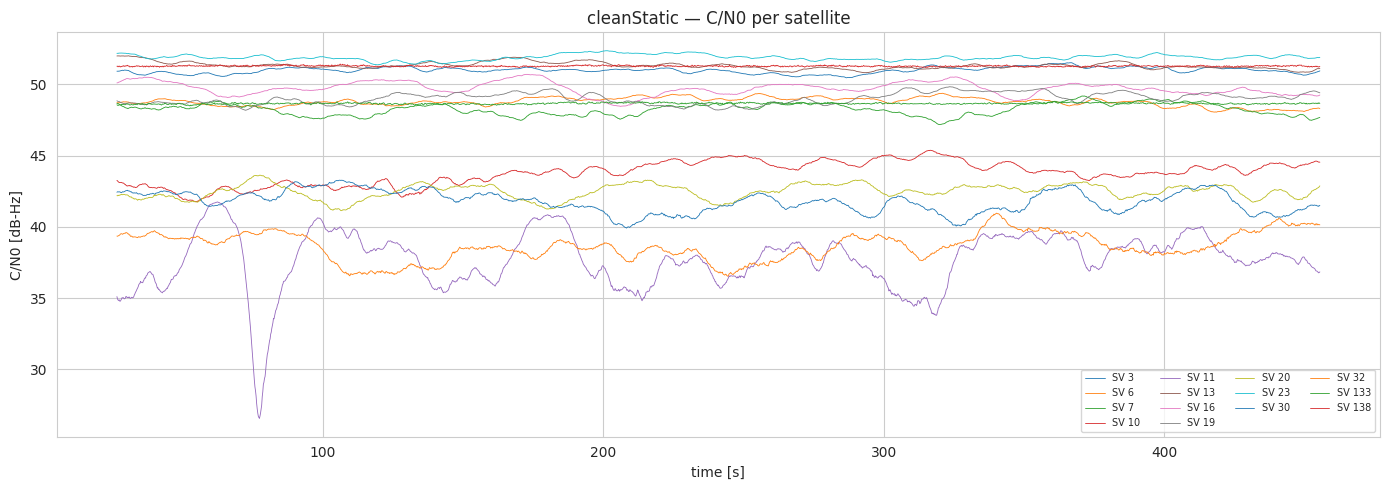


C/N0 stats: mean=46.7 std=4.8 min=26.5 max=52.7


In [19]:
# C/N0 over time per SV — cleanStatic
fig, ax = plt.subplots(figsize=(14, 5))
for txid, g in ch_clean[ch_clean['valid_flag'] == 1].groupby('txid'):
    ax.plot(g['t_rel'], g['cn0_dbhz'], label=f'SV {txid}', linewidth=0.6)
ax.set_xlabel('time [s]'); ax.set_ylabel('C/N0 [dB-Hz]')
ax.set_title('cleanStatic — C/N0 per satellite')
ax.legend(loc='lower right', ncol=4, fontsize=7)
plt.tight_layout(); plt.show()

print(f'\nC/N0 stats: mean={ch_clean["cn0_dbhz"].mean():.1f} std={ch_clean["cn0_dbhz"].std():.1f} min={ch_clean["cn0_dbhz"].min():.1f} max={ch_clean["cn0_dbhz"].max():.1f}')

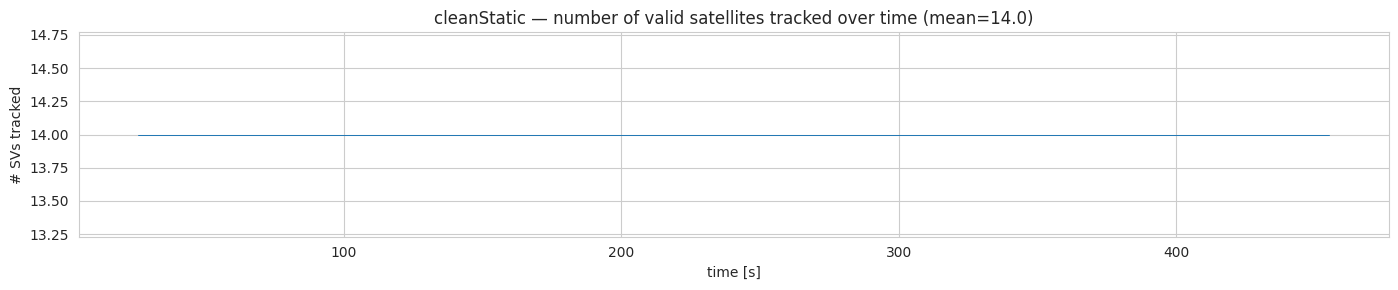

In [20]:
# How many SVs are tracked at each second?
ch_clean['t_int'] = ch_clean['t_rel'].astype(int)
sv_count = ch_clean[ch_clean['valid_flag'] == 1].groupby('t_int')['txid'].nunique()
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(sv_count.index, sv_count.values, linewidth=0.7)
ax.set_xlabel('time [s]'); ax.set_ylabel('# SVs tracked')
ax.set_title(f'cleanStatic — number of valid satellites tracked over time (mean={sv_count.mean():.1f})')
plt.tight_layout(); plt.show()

## 2. ds7 — przegląd z naniesionym timeline spoofingu

In [21]:
ch_ds7 = load_channel('ds7')
print(f'Rows: {len(ch_ds7):,}')
print(f'Time range: {ch_ds7["t_rel"].min():.1f} – {ch_ds7["t_rel"].max():.1f} s')
print(f'Unique TXIDs: {sorted(ch_ds7["txid"].unique())}')
print(f'Error flag distribution: {ch_ds7["error_flag"].value_counts().head(10).to_dict()}')

# Did GRID's own detector raise spoofing flag (bit 1)?
spoof_bit = (ch_ds7['error_flag'].astype(int) & 0b10) > 0
print(f'\nGRID receiver self-flagged spoofing: {spoof_bit.sum():,} / {len(ch_ds7):,} epochs ({100*spoof_bit.mean():.2f}%)')
if spoof_bit.any():
    first_flag = ch_ds7.loc[spoof_bit, 't_rel'].min()
    print(f'First flag at t={first_flag:.1f}s')

Rows: 32,732
Time range: 0.0 – 467.4 s
Unique TXIDs: [np.int64(3), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(13), np.int64(16), np.int64(19), np.int64(20), np.int64(23), np.int64(30), np.int64(32), np.int64(133), np.int64(138)]
Error flag distribution: {0.0: 32687, 1.0: 45}

GRID receiver self-flagged spoofing: 0 / 32,732 epochs (0.00%)


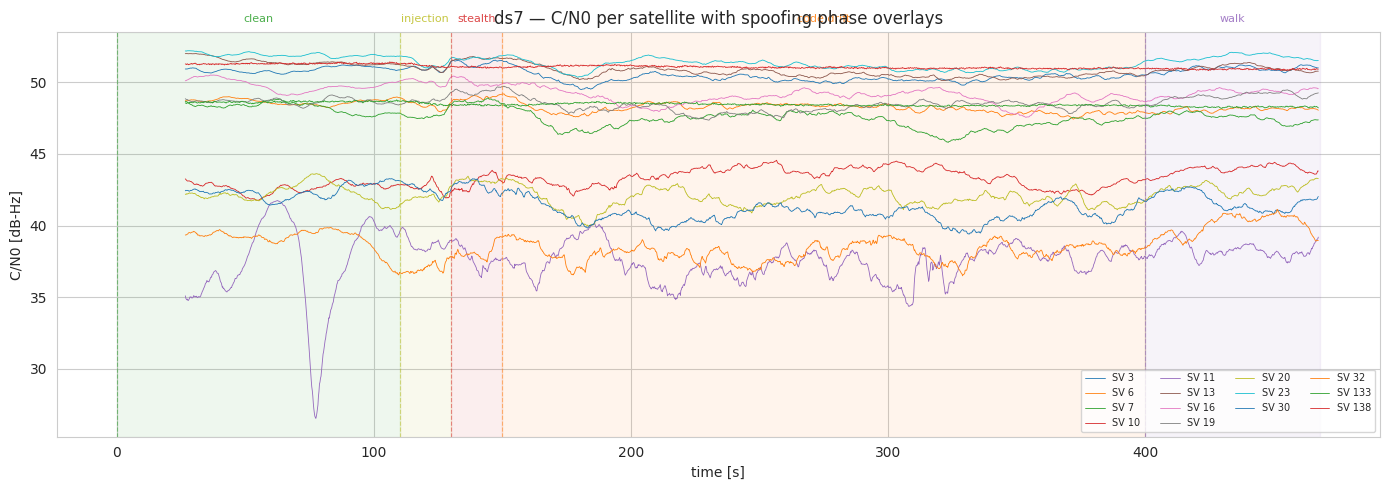

In [22]:
# C/N0 with spoofing phases highlighted
fig, ax = plt.subplots(figsize=(14, 5))
for txid, g in ch_ds7[ch_ds7['valid_flag'] == 1].groupby('txid'):
    ax.plot(g['t_rel'], g['cn0_dbhz'], label=f'SV {txid}', linewidth=0.6)
ax.set_xlabel('time [s]'); ax.set_ylabel('C/N0 [dB-Hz]')
ax.set_title('ds7 — C/N0 per satellite with spoofing phase overlays')
ax.legend(loc='lower right', ncol=4, fontsize=7)
annotate_ds7(ax)
plt.tight_layout(); plt.show()

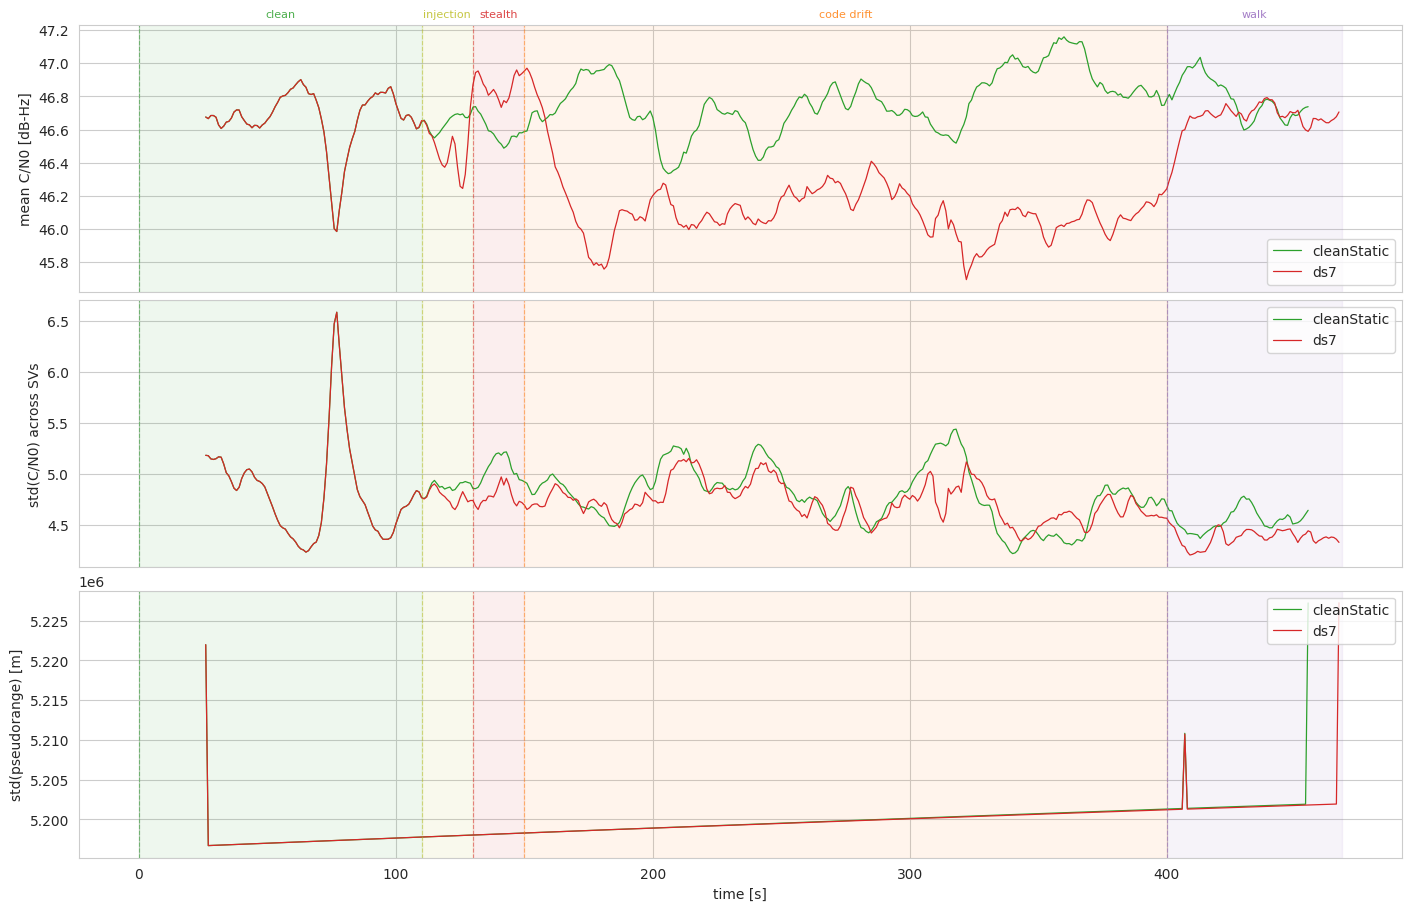

In [23]:
# Per-epoch aggregates: mean C/N0 across all valid SVs — clean vs ds7 overlay
def agg_per_epoch(df):
    g = df[df['valid_flag'] == 1].groupby('t_int')
    return pd.DataFrame({
        'cn0_mean': g['cn0_dbhz'].mean(),
        'cn0_std':  g['cn0_dbhz'].std(),
        'cn0_min':  g['cn0_dbhz'].min(),
        'pr_std':   g['pseudorange_m'].std(),
        'doppler_std': g['doppler_hz'].std(),
        'n_sv':     g['txid'].nunique(),
    })

ch_clean['t_int'] = ch_clean['t_rel'].astype(int)
ch_ds7['t_int']   = ch_ds7['t_rel'].astype(int)
agg_clean = agg_per_epoch(ch_clean)
agg_ds7   = agg_per_epoch(ch_ds7)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

axes[0].plot(agg_clean.index, agg_clean['cn0_mean'], label='cleanStatic', color='tab:green', linewidth=0.9)
axes[0].plot(agg_ds7.index,   agg_ds7['cn0_mean'],   label='ds7',         color='tab:red',   linewidth=0.9)
axes[0].set_ylabel('mean C/N0 [dB-Hz]')
axes[0].legend(loc='lower right')
mark_phases(axes[0])
label_phases(axes[0])  # text labels only on top axis

axes[1].plot(agg_clean.index, agg_clean['cn0_std'], label='cleanStatic', color='tab:green', linewidth=0.9)
axes[1].plot(agg_ds7.index,   agg_ds7['cn0_std'],   label='ds7',         color='tab:red',   linewidth=0.9)
axes[1].set_ylabel('std(C/N0) across SVs')
axes[1].legend(loc='upper right')
mark_phases(axes[1])

axes[2].plot(agg_clean.index, agg_clean['pr_std'], label='cleanStatic', color='tab:green', linewidth=0.9)
axes[2].plot(agg_ds7.index,   agg_ds7['pr_std'],   label='ds7',         color='tab:red',   linewidth=0.9)
axes[2].set_ylabel('std(pseudorange) [m]')
axes[2].set_xlabel('time [s]')
axes[2].legend(loc='upper right')
mark_phases(axes[2])

plt.show()

**Czego szukamy w wykresach powyżej:**
- `mean C/N0` — czy podczas spoofingu (zwłaszcza stealth 130-150s) widać różnicę? Jeśli nie, to potwierdza że stealth jest naprawdę cichy.
- `std(C/N0) across SVs` — spoofer często wyrównuje moce, więc spread powinien się zmniejszyć podczas spoofingu.
- `std(pseudorange)` — w fazie code drift (150-400s) powinien drastycznie wzrosnąć.

## 3. I/Q correlator — `iq.mat`

Wysokorate I/Q (kHz). Najtwardsze sygnatury: amplituda `√(I²+Q²)` i faza `atan2(Q, I)` per SV per czas.

In [24]:
iq_clean = load_iq('cleanStatic')
iq_ds7   = load_iq('ds7')
print(f'cleanStatic iq.mat: {len(iq_clean):,} rows, {iq_clean["txid"].nunique()} SVs')
print(f'ds7 iq.mat:         {len(iq_ds7):,} rows, {iq_ds7["txid"].nunique()} SVs')
print(f'\nSample rate (clean): ~{len(iq_clean) / iq_clean["t_rel"].max() / iq_clean["txid"].nunique():.0f} Hz per SV')

cleanStatic iq.mat: 1,001,176 rows, 14 SVs
ds7 iq.mat:         1,027,576 rows, 14 SVs

Sample rate (clean): ~157 Hz per SV


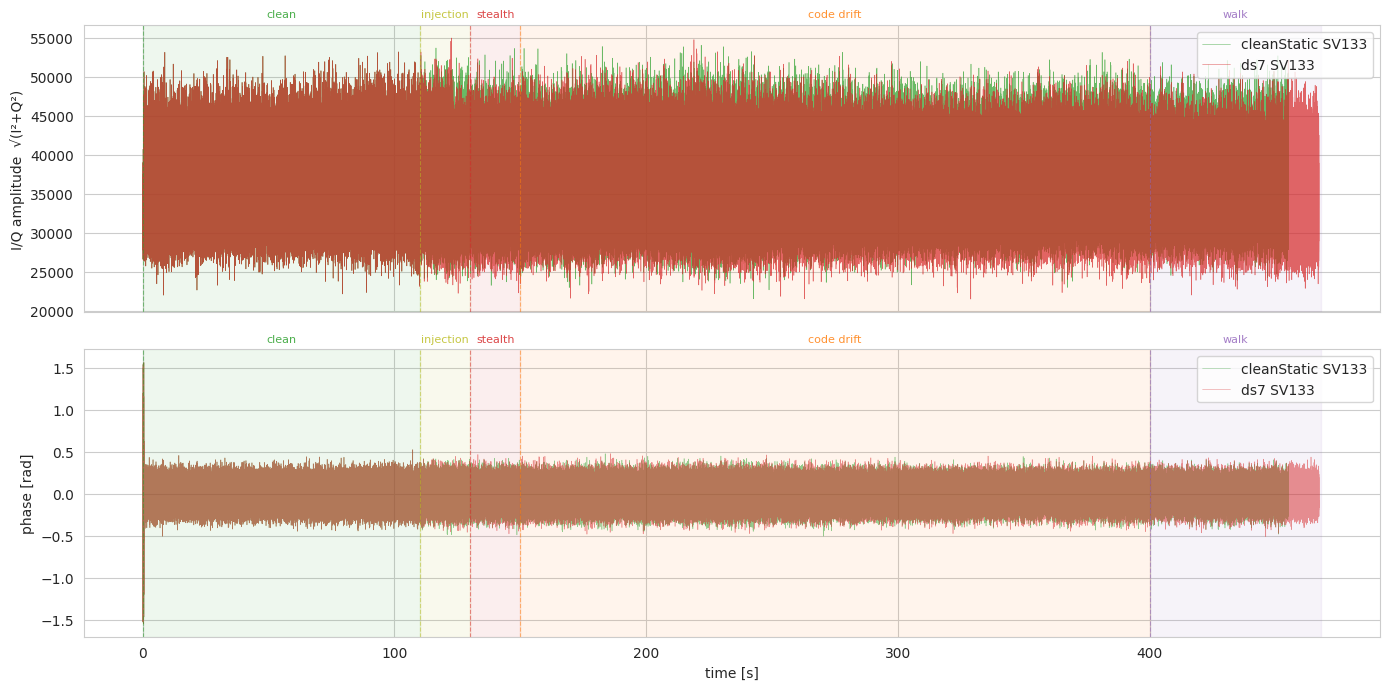

In [25]:
# Pick the most-tracked SV in ds7 and plot its IQ amplitude over time, both scenarios
best_sv = iq_ds7['txid'].value_counts().index[0]
iqc = iq_clean[iq_clean['txid'] == best_sv].sort_values('t_rel')
iqd = iq_ds7[iq_ds7['txid'] == best_sv].sort_values('t_rel')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(iqc['t_rel'], iqc['amp'], label=f'cleanStatic SV{best_sv}', color='tab:green', linewidth=0.4, alpha=0.7)
axes[0].plot(iqd['t_rel'], iqd['amp'], label=f'ds7 SV{best_sv}',         color='tab:red',   linewidth=0.4, alpha=0.7)
axes[0].set_ylabel('I/Q amplitude  √(I²+Q²)'); axes[0].legend()
annotate_ds7(axes[0])

axes[1].plot(iqc['t_rel'], iqc['phase'], label=f'cleanStatic SV{best_sv}', color='tab:green', linewidth=0.4, alpha=0.5)
axes[1].plot(iqd['t_rel'], iqd['phase'], label=f'ds7 SV{best_sv}',         color='tab:red',   linewidth=0.4, alpha=0.5)
axes[1].set_ylabel('phase [rad]'); axes[1].set_xlabel('time [s]'); axes[1].legend()
annotate_ds7(axes[1])

plt.tight_layout(); plt.show()

## 4. Korelator wielotapowy — `iqtaps.mat`

**41 tapów** in-phase + 41 quadrature. Pozwala rekonstruować kształt funkcji autokorelacji wokół pić Promptu — to jest podstawa SQM (delta metric, ratio metric, ELP).

In [26]:
iqtaps_clean = scipy.io.loadmat(DATA / 'cleanStatic' / 'iqtaps.mat')['iqtaps'].T
iqtaps_ds7   = scipy.io.loadmat(DATA / 'ds7' / 'iqtaps.mat')['iqtaps'].T
print(f'cleanStatic iqtaps shape: {iqtaps_clean.shape}  (cols 0-3: rrt_wk, rrt_sow, signal_type, txid; 4-44: I taps; 45-85: Q taps)')
n_taps = (iqtaps_clean.shape[1] - 4) // 2
print(f'Number of correlator taps: {n_taps}')

# t_rel for both
iqtaps_clean_t = iqtaps_clean[:, 1] - iqtaps_clean[0, 1]
iqtaps_ds7_t   = iqtaps_ds7[:, 1]   - iqtaps_ds7[0, 1]
iqtaps_clean_tx = iqtaps_clean[:, 3].astype(int)
iqtaps_ds7_tx   = iqtaps_ds7[:, 3].astype(int)

cleanStatic iqtaps shape: (1001506, 86)  (cols 0-3: rrt_wk, rrt_sow, signal_type, txid; 4-44: I taps; 45-85: Q taps)
Number of correlator taps: 41


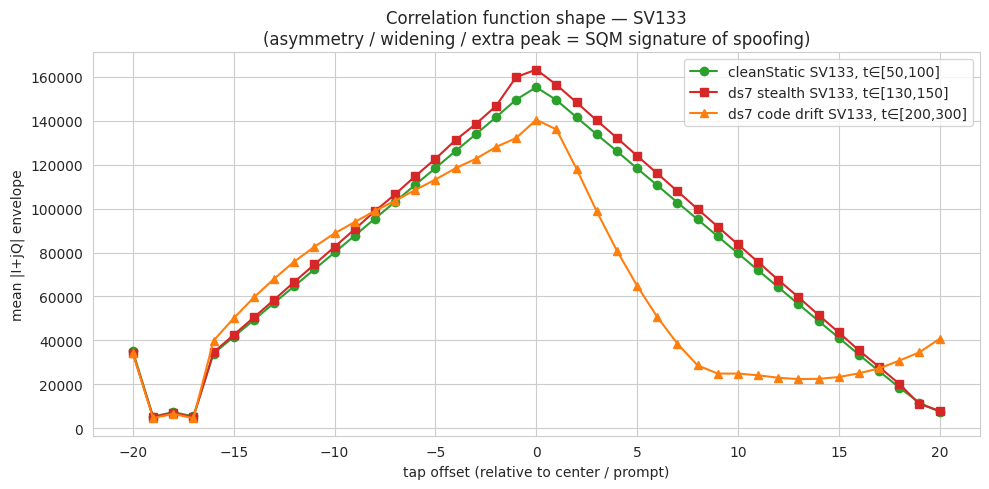

In [27]:
# Compute |I+jQ| envelope across taps — this gives the correlation-function shape
# Pick best SV and show shape clean vs spoofed at chosen times
def get_envelope(taps_arr, n_taps):
    I = taps_arr[:, 4:4+n_taps]
    Q = taps_arr[:, 4+n_taps:4+2*n_taps]
    return np.hypot(I, Q)  # (N, n_taps)

# Clean: average correlation envelope at t in [50, 100]
mask_c = (iqtaps_clean_t >= 50) & (iqtaps_clean_t <= 100) & (iqtaps_clean_tx == best_sv)
env_clean = get_envelope(iqtaps_clean[mask_c], n_taps).mean(axis=0)

# ds7 stealth: average envelope in 130-150 (spoofer in control, stealthy)
mask_s = (iqtaps_ds7_t >= 130) & (iqtaps_ds7_t <= 150) & (iqtaps_ds7_tx == best_sv)
env_stealth = get_envelope(iqtaps_ds7[mask_s], n_taps).mean(axis=0) if mask_s.any() else None

# ds7 code drift: 200-300
mask_d = (iqtaps_ds7_t >= 200) & (iqtaps_ds7_t <= 300) & (iqtaps_ds7_tx == best_sv)
env_drift = get_envelope(iqtaps_ds7[mask_d], n_taps).mean(axis=0) if mask_d.any() else None

fig, ax = plt.subplots(figsize=(10, 5))
tap_idx = np.arange(n_taps) - n_taps // 2  # center on prompt (assumed middle tap)
ax.plot(tap_idx, env_clean, 'o-', label=f'cleanStatic SV{best_sv}, t∈[50,100]', color='tab:green')
if env_stealth is not None:
    ax.plot(tap_idx, env_stealth, 's-', label=f'ds7 stealth SV{best_sv}, t∈[130,150]', color='tab:red')
if env_drift is not None:
    ax.plot(tap_idx, env_drift, '^-', label=f'ds7 code drift SV{best_sv}, t∈[200,300]', color='tab:orange')
ax.set_xlabel('tap offset (relative to center / prompt)')
ax.set_ylabel('mean |I+jQ| envelope')
ax.set_title(f'Correlation function shape — SV{best_sv}\n(asymmetry / widening / extra peak = SQM signature of spoofing)')
ax.legend()
plt.tight_layout(); plt.show()

## 5. `symmdiff.mat` — symmetric difference (gotowy SQM-like feature)

Format complex128, 24 kolumny × ~1M wierszy. Brak oficjalnej dokumentacji — eksplorujemy.

In [28]:
sd_clean = scipy.io.loadmat(DATA / 'cleanStatic' / 'symmdiff.mat')['symmdiff'].T
sd_ds7   = scipy.io.loadmat(DATA / 'ds7' / 'symmdiff.mat')['symmdiff'].T
print(f'cleanStatic symmdiff: {sd_clean.shape}, dtype={sd_clean.dtype}')
print(f'ds7 symmdiff:         {sd_ds7.shape}, dtype={sd_ds7.dtype}')

# First few cols may be time/metadata (not complex), so check abs of imag part per col
imag_per_col = np.abs(sd_clean.imag).mean(axis=0)
print(f'\nMean |imag| per column (probably time/meta cols if ~0):')
for i, v in enumerate(imag_per_col):
    print(f'  col {i:2d}: |imag|_mean = {v:.4g}')

cleanStatic symmdiff: (1001506, 24), dtype=complex128
ds7 symmdiff:         (1027906, 24), dtype=complex128

Mean |imag| per column (probably time/meta cols if ~0):
  col  0: |imag|_mean = 0
  col  1: |imag|_mean = 0
  col  2: |imag|_mean = 0
  col  3: |imag|_mean = 0
  col  4: |imag|_mean = 1608
  col  5: |imag|_mean = 2409
  col  6: |imag|_mean = 3144
  col  7: |imag|_mean = 3805
  col  8: |imag|_mean = 4408
  col  9: |imag|_mean = 4952
  col 10: |imag|_mean = 5429
  col 11: |imag|_mean = 5833
  col 12: |imag|_mean = 6183
  col 13: |imag|_mean = 6482
  col 14: |imag|_mean = 6617
  col 15: |imag|_mean = 6715
  col 16: |imag|_mean = 6780
  col 17: |imag|_mean = 6805
  col 18: |imag|_mean = 6802
  col 19: |imag|_mean = 6773
  col 20: |imag|_mean = 6724
  col 21: |imag|_mean = 6655
  col 22: |imag|_mean = 6578
  col 23: |imag|_mean = 6460


## 6. Wideband power — `cd1powerXMHz.mat` / `tb7powerXMHz.mat`

Proxy AGC. Łatwo wykryć overpowering. Dla cleanStatic prefiks to `cd1`, dla ds7 to `tb7`.

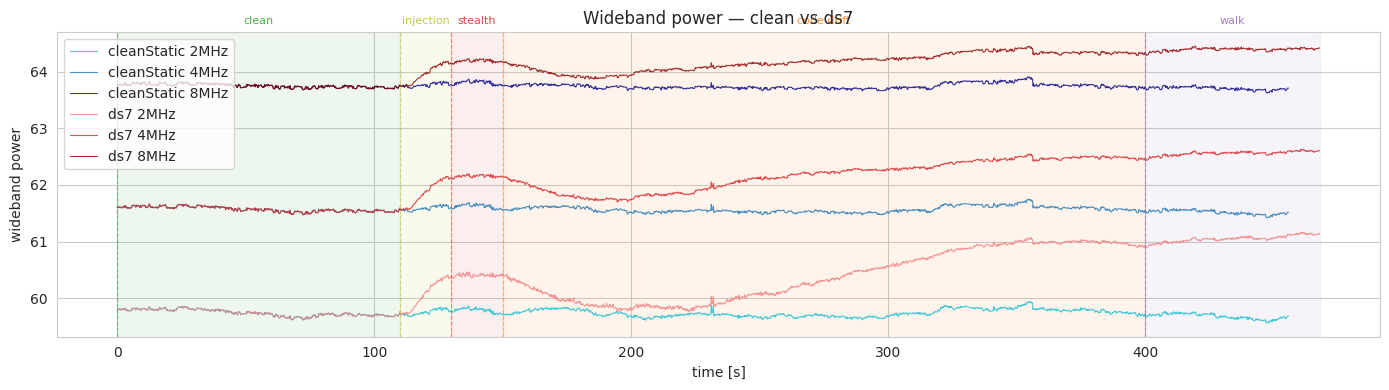

In [29]:
def load_power(scenario, prefix, mhz):
    p = DATA / scenario / f'{prefix}power{mhz}MHz.mat'
    if not p.exists():
        return None
    d = scipy.io.loadmat(p)
    t = d['t'].flatten(); pw = d['power'].flatten()
    t_rel = t - t[0]
    return t_rel, pw

fig, ax = plt.subplots(figsize=(14, 4))
for mhz, color in zip([2, 4, 8], ['tab:cyan', 'tab:blue', 'navy']):
    r = load_power('cleanStatic', 'cd1', mhz)
    if r: ax.plot(r[0], r[1], label=f'cleanStatic {mhz}MHz', color=color, linewidth=0.8, alpha=0.8)
for mhz, color in zip([2, 4, 8], ['lightcoral', 'tab:red', 'darkred']):
    r = load_power('ds7', 'tb7', mhz)
    if r: ax.plot(r[0], r[1], label=f'ds7 {mhz}MHz', color=color, linewidth=0.8, alpha=0.8)
ax.set_xlabel('time [s]'); ax.set_ylabel('wideband power')
ax.set_title('Wideband power — clean vs ds7')
ax.legend()
annotate_ds7(ax)
plt.tight_layout(); plt.show()

## 7. Navigation solution — `navsol.mat`

Odbiornik ECEF position + clock error. Dla statycznego cleanStatic pozycja powinna być stabilna; dla ds7 po fazie code drift powinna zacząć dryfować.

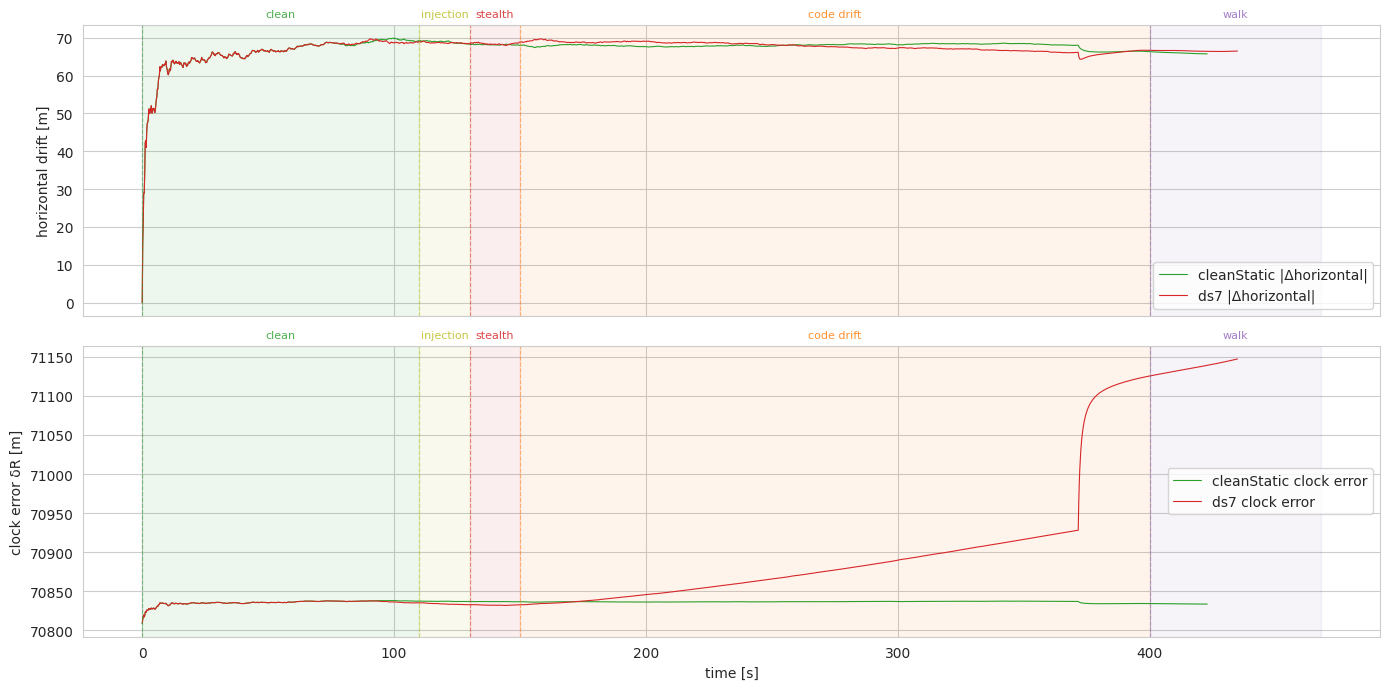

In [30]:
ns_clean = load_navsol('cleanStatic')
ns_ds7   = load_navsol('ds7')

# Position residuals from initial position (per scenario)
for df in (ns_clean, ns_ds7):
    df['dx'] = df['X'] - df['X'].iloc[0]
    df['dy'] = df['Y'] - df['Y'].iloc[0]
    df['dz'] = df['Z'] - df['Z'].iloc[0]
    df['d_horiz'] = np.hypot(df['dx'], df['dy'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(ns_clean['t_rel'], ns_clean['d_horiz'], label='cleanStatic |Δhorizontal|', color='tab:green', linewidth=0.8)
axes[0].plot(ns_ds7['t_rel'],   ns_ds7['d_horiz'],   label='ds7 |Δhorizontal|',         color='tab:red',   linewidth=0.8)
axes[0].set_ylabel('horizontal drift [m]'); axes[0].legend()
annotate_ds7(axes[0])

axes[1].plot(ns_clean['t_rel'], ns_clean['deltR_m'], label='cleanStatic clock error', color='tab:green', linewidth=0.8)
axes[1].plot(ns_ds7['t_rel'],   ns_ds7['deltR_m'],   label='ds7 clock error',         color='tab:red',   linewidth=0.8)
axes[1].set_ylabel('clock error δR [m]'); axes[1].set_xlabel('time [s]'); axes[1].legend()
annotate_ds7(axes[1])

plt.tight_layout(); plt.show()

## 8. Wnioski + plan feature engineering

**Co już teraz możemy stwierdzić** (zostanie potwierdzone wykresami):
- `cn0_mean`, `cn0_std`, `pr_std` — najprawdopodobniej widzą code-drift fazę 150+, mogą *nie widzieć* stealth 130-150.
- Ksztalt funkcji korelacji z `iqtaps` — powinien rozjeżdżać się od czystego nawet w fazie stealth (dlatego SQM jest złoty).
- `clock error δR` z navsol w ds7 powinien w fazie 400-468 osiągnąć ~382 m (1.273 µs).

**Plan baseline'u (L1 — XGBoost):**
1. Window every 1 second of channel.mat data, aggregate per epoch:
   - `cn0_mean`, `cn0_std`, `cn0_min`, `cn0_max`, `n_sv_tracked`
   - `doppler_std`, `pseudorange_std`
   - `error_flag_any` (czy GRID coś flagnął)
2. Per-second SQM features z iqtaps:
   - `corr_envelope_asymmetry` (delta metric)
   - `corr_envelope_ratio` (ratio metric)
   - `early_late_phase` (ELP)
3. Wideband power AGC: `power_2MHz_zscore`, `power_4MHz_zscore`, `power_8MHz_zscore`
4. Navsol residuals: `clock_error_drift`, `position_drift_horiz`

**Label:** czas-zależna binarna w ds7: `t<110 → 0`, `t≥110 → 1`. Plus per-phase metrics (clean/inj/stealth/drift/walk).

**Train/test:** wystarczy podzielić cleanStatic+ds3 jako train, ds7 jako test (out-of-distribution — naprawdę nigdy nie widziany scenariusz). Dodatkowo z cleanStatic robimy windows oznaczone jako 0, z ds7 t≥110 oznaczone jako 1.

Następny notebook: `02_feature_extraction.ipynb` zaimplementuje to wszystko jako funkcję `(scenario_path) → DataFrame[t_int × features]`.